# Data Understanding

# import data

In [ ]:
from google.colab import files
import io
import pandas as pd

# 1. UNTUK UPLOAD FILE
uploaded = files.upload()

# 2. AMBIL NAMA FILE
nama_file = list(uploaded.keys())[0]

# 3. JALANKAN KODE MEMBACA CSV
data = pd.read_csv(io.BytesIO(uploaded[nama_file]), sep=';', skiprows=4)

# 4. TAMPILKAN DATA
data.head(5)

Saving youtube-comments.csv to youtube-comments (2).csv


,S.No,Name (click to view profile),Date,Likes,Comment,(view source)
0,1,"=HYPERLINK(""http://www.youtube.com/@ferryirwan...",2026-05-13T07:53:03Z,3855,hallo warga sipil sekalian semoga ini menjelas...,"=HYPERLINK(""https://www.youtube.com/watch?v=2F..."
1,2,"=HYPERLINK(""http://www.youtube.com/@budihartan...",2026-06-06T06:52:13Z,0,Entah kenapa hati kecil berkata seorang Ferry ...,"=HYPERLINK(""https://www.youtube.com/watch?v=2F..."
2,3,"=HYPERLINK(""http://www.youtube.com/@SugiYono-b...",2026-06-06T05:28:08Z,0,Kekliruan hutang terlalu besar era Jokowi seka...,"=HYPERLINK(""https://www.youtube.com/watch?v=2F..."
3,4,"=HYPERLINK(""http://www.youtube.com/@SugiYono-b...",2026-06-06T05:27:35Z,0,lihat yg buat konten irfan irwandi itu termul ...,"=HYPERLINK(""https://www.youtube.com/watch?v=2F..."
4,5,"=HYPERLINK(""http://www.youtube.com/@SugiYono-b...",2026-06-06T05:25:33Z,0,Kekliruan hutang terlalu besar era Jokowi seka...,"=HYPERLINK(""https://www.youtube.com/watch?v=2F..."


In [ ]:
data.shape

(4996, 6)

In [ ]:
data.dtypes

,0
S.No,int64
Name (click to view profile),object
Date,object
Likes,int64
Comment,object
(view source),object


In [ ]:
# === CRITERIA 2: ANALISIS KARAKTERISTIK & STATISTIK DESKRIPTIF DASAR ===

# Tampilkan informasi ringkas struktur kolom dan missing values
print("--- Informasi Struktur Data ---")
data.info()

# Tampilkan statistik deskriptif untuk kolom numerik (seperti kolom 'Likes')
print("\n--- Ringkasan Statistik Dasar (Kolom Numerik) ---")
print(data.describe())

--- Informasi Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4996 entries, 0 to 4995
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   S.No                          4996 non-null   int64 
 1   Name (click to view profile)  4996 non-null   object
 2   Date                          4996 non-null   object
 3   Likes                         4996 non-null   int64 
 4   Comment                       4996 non-null   object
 5   (view source)                 4996 non-null   object
dtypes: int64(2), object(4)
memory usage: 234.3+ KB

--- Ringkasan Statistik Dasar (Kolom Numerik) ---
              S.No        Likes
count  4996.000000  4996.000000
mean   2498.500000     2.210168
std    1442.365303    63.404782
min       1.000000     0.000000
25%    1249.750000     0.000000
50%    2498.500000     0.000000
75%    3747.250000     0.000000
max    4996.000000  3855.000000


In [ ]:
# Mengubah kolom 'Date' dari tipe object menjadi datetime
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Verifikasi ulang untuk memastikan tipenya sudah berubah
print("--- Tipe Data Kolom Setelah Dikonversi ---")
print(data['Date'].dtypes)

--- Tipe Data Kolom Setelah Dikonversi ---
datetime64[ns, UTC]


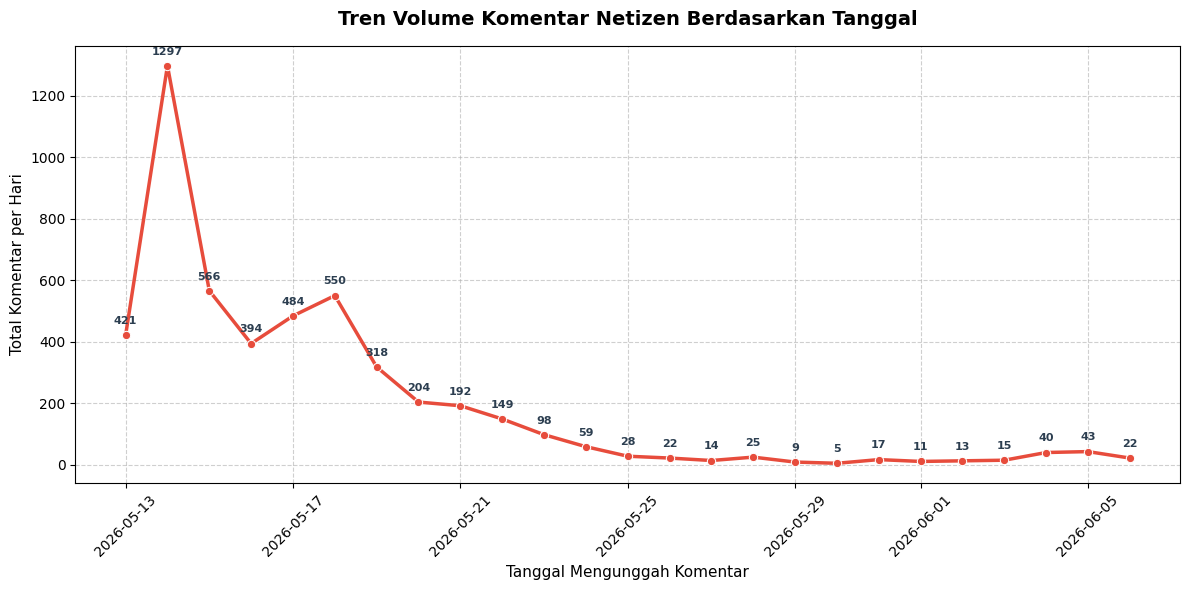

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. AMBIL BAGIAN TANGGALNYA SAJA (TANPA JAM/ZONA WAKTU)
# =========================================================
# Ganti data_bersih menjadi data jika nama variabel awalmu adalah 'data'
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Kita gunakan .dt.date untuk mengelompokkan data berdasarkan hari
data['Tanggal'] = data['Date'].dt.date

# Hitung jumlah komentar per tanggal, lalu urutkan berdasarkan kronologi tanggal
tren_tanggal = data['Tanggal'].value_counts().sort_index().reset_index()
tren_tanggal.columns = ['Tanggal', 'Jumlah_Komentar']

# =========================================================
# 2. MEMBUAT VISUALISASI GRAFIK GARIS (LINE CHART)
# =========================================================
plt.figure(figsize=(12, 6))

# Membuat grafik garis dengan titik (marker) di setiap tanggal
sns.lineplot(x='Tanggal', y='Jumlah_Komentar', data=tren_tanggal,
             marker='o', markersize=6, linewidth=2.5, color='#e74c3c')

# Mengatur Estetika Grafik
plt.title('Tren Volume Komentar Netizen Berdasarkan Tanggal', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tanggal Mengunggah Komentar', fontsize=11)
plt.ylabel('Total Komentar per Hari', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Memutar teks tanggal di sumbu X agar tidak saling bertabrakan
plt.xticks(rotation=45)

# Menampilkan angka jumlah komentar tepat di atas titik koordinat
for i in range(len(tren_tanggal)):
    plt.annotate(f"{tren_tanggal['Jumlah_Komentar'].iloc[i]}",
                 (tren_tanggal['Tanggal'].iloc[i], tren_tanggal['Jumlah_Komentar'].iloc[i]),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha='center', fontsize=8, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan indeks berupa komentar menjadi kolom biasa bernama 'Comment'
if 'Comment' not in data.columns:
    data = data.reset_index()

# Pastikan kolom 'Comment' sudah muncul kembali
print(data.columns.tolist())

['S.No', 'Name (click to view profile)', 'Date', 'Likes', 'Comment', '(view source)', 'Tanggal']


In [ ]:
# === CRITERIA 3 & 4: PENILAIAN KECUKUPAN DATA & KRITERIA PEMILIHAN DATA ===

# 1. Menilai Kecukupan Data berdasarkan ukuran data saat ini
jumlah_baris = data.shape[0]
print(f"Total Sampel Data Awal: {jumlah_baris} baris.")

if jumlah_baris > 1000:
    print("Rekomendasi Teknikal: Ukuran sampel data > 1000 baris. Secara statistik, volume data SUDAH CUKUP, valid, dan representatif untuk menarik kesimpulan distribusi sentimen publik.")
else:
    print("Rekomendasi Teknikal: Data kurang memenuhi batas minimum kecukupan data.")

# 2. Pemilihan Data Berdasarkan Aturan Teknis & Aturan Privasi (Data Governance)
# Kita memilih kolom 'Comment' sebagai fitur tekstual utama dan 'Likes' atau 'Date' sebagai fitur pendukung.
# Kolom 'Name (click to view profile)' kita abaikan.
fitur_terpilih = data[['Comment', 'Likes', 'Date']].copy()

print("\n--- Hasil Pemilihan Fitur ---")
print("Fitur yang dipilih untuk pemodelan: 'Comment', 'Likes', 'Date'")
fitur_terpilih.head(5)

Total Sampel Data Awal: 4996 baris.
Rekomendasi Teknikal: Ukuran sampel data > 1000 baris. Secara statistik, volume data SUDAH CUKUP, valid, dan representatif untuk menarik kesimpulan distribusi sentimen publik.

--- Hasil Pemilihan Fitur ---
Fitur yang dipilih untuk pemodelan: 'Comment', 'Likes', 'Date'


,Comment,Likes,Date
0,hallo warga sipil sekalian semoga ini menjelas...,3855,2026-05-13 07:53:03+00:00
1,Entah kenapa hati kecil berkata seorang Ferry ...,0,2026-06-06 06:52:13+00:00
2,Kekliruan hutang terlalu besar era Jokowi seka...,0,2026-06-06 05:28:08+00:00
3,lihat yg buat konten irfan irwandi itu termul ...,0,2026-06-06 05:27:35+00:00
4,Kekliruan hutang terlalu besar era Jokowi seka...,0,2026-06-06 05:25:33+00:00


In [ ]:
fitur_terpilih['Comment'].duplicated().sum()

np.int64(39)

# Data Preparation

In [ ]:
# === CRITERIA 5: PEMBERSIHAN DATA KOTOR (DATA CLEANING) ===

# 1. Menghapus komentar yang duplikat (Spam)
data_bersih = fitur_terpilih.drop_duplicates(subset=['Comment'])

# 2. Menghapus komentar yang kosong (Missing Value)
data_bersih = data_bersih.dropna(subset=['Comment'])

# 3. Membuat salinan data yang aman
data_bersih = data_bersih.copy()

print("--- Hasil Proses Pembersihan Data ---")
print(f"Jumlah baris awal sebelum cleaning : {fitur_terpilih.shape[0]}")
# Assign data_clean before using it in the f-string
data_clean = data_bersih.shape[0]
print(f"Jumlah baris setelah cleaning      : {data_clean}")
print(f"Jumlah data kotor/spam yang dibuang : {fitur_terpilih.shape[0] - data_bersih.shape[0]}")

# Validasi akhir untuk membuktikan keunikan kolom target kepada asesor
print(f"\nApakah kolom 'Comment' sekarang sudah bersih dan 100% unik? {data_bersih['Comment'].is_unique}")

--- Hasil Proses Pembersihan Data ---
Jumlah baris awal sebelum cleaning : 4996
Jumlah baris setelah cleaning      : 4957
Jumlah data kotor/spam yang dibuang : 39

Apakah kolom 'Comment' sekarang sudah bersih dan 100% unik? True


In [ ]:
# === CRITERIA 6: REPRESENTASI FITUR & REKAYASA FITUR (TEXT PREPROCESSING) ===
import re
import pandas as pd

def rekayasa_fitur_teks(teks):
    # Jika data bukan string (misal kosong/float), jadikan string kosong
    if not isinstance(teks, str):
        return ""

    # 1. Case Folding: Mengubah huruf menjadi kecil semua
    teks = teks.lower()

    # 2. Menghapus URL / Link Website jika ada
    teks = re.sub(r'http\S+|www\S+|https\S+', '', teks)

    # 3. Menghapus Hashtag (#kata) dan Mention (@kata)
    teks = re.sub(r'#\w+|@\w+', '', teks)

    # 4. Menghapus Angka, Tanda Baca, Simbol, dan Emoji
    teks = re.sub(r'[^a-z\s]', '', teks)

    # 5. Menghapus spasi berlebih di awal, tengah, atau akhir teks
    teks = teks.strip()
    teks = re.sub(r'\s+', ' ', teks)

    return teks

# Terapkan rekayasa fitur untuk membuat kolom teks baru yang sudah bersih total
data_bersih['Clean_Comment'] = data_bersih['Comment'].apply(rekayasa_fitur_teks)

# Menghapus baris yang mungkin jadi kosong setelah simbol/emojinya dibuang semua
data_bersih = data_bersih[data_bersih['Clean_Comment'] != ''].copy()

print("--- Hasil Rekayasa Fitur Teks ---")

# =========================================================================
# AGAR TABEL RAPI, LEBAR TERBATAS, DAN OTOMATIS WRAP TEXT (PINDAH BARIS)
# =========================================================================
# 1. Mengatur agar teks di dalam kolom tidak dipotong (... ) oleh Pandas
pd.set_option('display.max_colwidth', None)

# 2. Menampilkan 5 data teratas dengan gaya visualisasi HTML bertipe 'left' (Rata Kiri)
#    dan menyisipkan properti CSS untuk membatasi lebar kolom maksimal 400 pixel.
data_bersih[['Comment', 'Clean_Comment']].head(5).style.set_properties(**{
    'text-align': 'left',
    'max-width': '400px',
    'white-space': 'normal',
    'vertical-align': 'top'
})

--- Hasil Rekayasa Fitur Teks ---


,Comment,Clean_Comment
0,hallo warga sipil sekalian semoga ini menjelaskan ya ❤,hallo warga sipil sekalian semoga ini menjelaskan ya
1,Entah kenapa hati kecil berkata seorang Ferry Irwandi masih lebih capable buat urus negara ini ketiban Presiden yg ada sekarang.. 😂,entah kenapa hati kecil berkata seorang ferry irwandi masih lebih capable buat urus negara ini ketiban presiden yg ada sekarang
2,"Kekliruan hutang terlalu besar era Jokowi sekarang kena dampaknya, whoosh, IKN,MBG semua program JOKOWI",kekliruan hutang terlalu besar era jokowi sekarang kena dampaknya whoosh iknmbg semua program jokowi
3,"lihat yg buat konten irfan irwandi itu termul gak pernah mbahas hutang masa jokowi,WHOOSH,IKN MBG itu hutang",lihat yg buat konten irfan irwandi itu termul gak pernah mbahas hutang masa jokowiwhooshikn mbg itu hutang
7,"gak lama abis video ini,, anggaran mbg di press, dan pimpinan bgn di pecat, dan jadi tersangka 👍👍... gw yakin mbg itu bagus, tapi gak harus sebesar itu anggaran nya, bisa bgt di press lagi.... Dan eksport harus bener2 digenjot bgt,dan import harus diteken, yang gak perlu kayak barang2 cina di shopee dan tiktok harus di atur biar gak semua asal bisa masuk... eksport komoditi sesegera mungkin buat satu pintu biar devisa masuk diatur sama negara, baru oligarki taipan di bayar lewat pemerintah pake rupiah, jadi dollar nya bisa diparkir aman sama pemerintah langsung ... dan per hari ini ada komitmen kuat untuk Kemenkeu dan BI bersinergi kuat.... keren Lo fer,, semua bahasan Lo di dengerin dan di aplikasikan sama pemerintah ❤❤❤",gak lama abis video ini anggaran mbg di press dan pimpinan bgn di pecat dan jadi tersangka gw yakin mbg itu bagus tapi gak harus sebesar itu anggaran nya bisa bgt di press lagi dan eksport harus bener digenjot bgtdan import harus diteken yang gak perlu kayak barang cina di shopee dan tiktok harus di atur biar gak semua asal bisa masuk eksport komoditi sesegera mungkin buat satu pintu biar devisa masuk diatur sama negara baru oligarki taipan di bayar lewat pemerintah pake rupiah jadi dollar nya bisa diparkir aman sama pemerintah langsung dan per hari ini ada komitmen kuat untuk kemenkeu dan bi bersinergi kuat keren lo fer semua bahasan lo di dengerin dan di aplikasikan sama pemerintah


In [ ]:
# === CRITERIA 7 & 8: PELABELAN DATA SESUAI SOP & MEMBANGUN ALGORITMA PEMODELAN ===
import numpy as np
import pandas as pd

# 1. Menetapkan SOP Pelabelan Aturan Sederhana (Rule-Based Sentimen)
def algoritma_sentimen_sederhana_detail(teks):
    # Kamus kata kunci bermuatan emosi
    kata_positif = ['bagus', 'baik', 'keren', 'mantap', 'hebat', 'luar', 'biasa',
                    'setuju', 'benar', 'tepat', 'pintar', 'cerdas', 'jenius',
                    'sukses', 'berhasil', 'maju', 'berkembang', 'sejahtera',
                    'optimis', 'harapan', 'solusi', 'dukung', 'mendukung',
                    'bangga', 'senang', 'suka', 'salut', 'kece', 'top', 'jos',
                    'valid', 'jelas', 'paham', 'ngerti', 'informatif', 'edukasi',
                    'bermanfaat', 'manfaat', 'capable', 'kompeten', 'ahli',
                    'bijak', 'logis', 'relevan', 'akurat', 'transparan', 'jujur',
                    'amanah', 'stabil', 'kuat', 'menguat', 'surplus', 'untung',
                    'profit', 'investasi', 'ekspor', 'hilirisasi', 'pertumbuhan',
                    'tumbuh', 'efisien', 'produktif', 'inovasi', 'berkualitas',
                    'meningkat', 'naik', 'devisa', 'modal', 'support',
                    'semangat', 'lanjut', 'konsisten']

    kata_negatif = ['jelek', 'stop', 'koruptor', 'korupsi', 'anak', 'becus', 'otak', 'prabowo', 'jokowi', 'buruk', 'gagal', 'salah', 'rugi',
                    'bodoh', 'owo', 'dollar', 'duit', 'asing', 'gas', 'rakyat', 'pajak', 'rupiah', 'wowo', 'goblok', 'tolol', 'idiot', 'dungu', 'bego',
                    'payah', 'parah', 'kacau', 'amburadul', 'semrawut',
                    'maling', 'rampok', 'dolar', 'ekonomi', 'uang', 'mbg', 'omon', 'lemah', 'manipulasi',
                    'bohong', 'dusta', 'tipu', 'penipu', 'pembohong','negara',
                    'hancur', 'bobrok', 'rusak', 'busuk', 'bangkrut',
                    'kolaps', 'bubar', 'ambruk', 'tenggelam', 'warga', 'wo',
                    'kecewa', 'sedih', 'marah', 'kesal', 'benci', 'muak',
                    'jijik', 'malu', 'takut', 'khawatir', 'cemas', 'resah',
                    'pesimis', 'melemah', 'lemah', 'defisit', 'utang', 'hutang',
                    'inflasi', 'phk', 'pengangguran', 'resesi', 'krisis',
                    'miskin', 'sengsara', 'menderita', 'berat', 'anjlok',
                    'terpuruk', 'terjepit', 'beban', 'mahal', 'membengkak',
                    'pecat', 'tersangka', 'lengser', 'ogah', 'menolak',
                    'protes', 'tolak', 'ingkar', 'khianat', 'pengkhianat',
                    'pemborosan', 'unfaedah', 'dipaksakan', 'pencitraan',
                    'merampok', 'perampokan', 'menjijikan', 'tong', 'kosong']

    # Hitung bobot kemunculan kata kunci
    hitung_pos = sum(1 for kata in kata_positif if kata in teks)
    hitung_neg = sum(1 for kata in kata_negatif if kata in teks)
    skor_akhir = hitung_pos - hitung_neg

    # Keputusan Label berdasarkan Skor Polaritas
    if skor_akhir > 0:
        label = 'Positif'
    elif skor_akhir < 0:
        label = 'Negatif'
    else:
        label = 'Netral'

    # Mengembalikan banyak nilai sekaligus untuk dijadikan kolom baru
    return pd.Series([hitung_pos, hitung_neg, skor_akhir, label])

# 2. Menjalankan Algoritma Pemodelan & Membuat Kolom Pembobotan Detail
data_bersih[['Bobot_Positif', 'Bobot_Negatif', 'Skor_Total', 'Sentiment_Model']] = data_bersih['Clean_Comment'].apply(algoritma_sentimen_sederhana_detail)

print("--- Hasil Proses Pelabelan & Tabel Pembobotan Skor ---")

# =========================================================================
# PENGATURAN TAMPILAN TABEL BIAR RAPI DAN TIDAK MELAR KE KANAN
# =========================================================================
pd.set_option('display.max_colwidth', None)

# Menampilkan 5 data teratas beserta kolom pembobotannya
kolom_tampil = ['Clean_Comment', 'Bobot_Positif', 'Bobot_Negatif', 'Skor_Total', 'Sentiment_Model']
data_bersih[kolom_tampil].head(5).style.set_properties(**{
    'text-align': 'left',
    'vertical-align': 'top'
}).set_properties(subset=['Clean_Comment'], **{
    'max-width': '350px',
    'white-space': 'normal'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center')]}
])

--- Hasil Proses Pelabelan & Tabel Pembobotan Skor ---


,Clean_Comment,Bobot_Positif,Bobot_Negatif,Skor_Total,Sentiment_Model
0,hallo warga sipil sekalian semoga ini menjelaskan ya,1,1,0,Netral
1,entah kenapa hati kecil berkata seorang ferry irwandi masih lebih capable buat urus negara ini ketiban presiden yg ada sekarang,1,1,0,Netral
2,kekliruan hutang terlalu besar era jokowi sekarang kena dampaknya whoosh iknmbg semua program jokowi,0,4,-4,Negatif
3,lihat yg buat konten irfan irwandi itu termul gak pernah mbahas hutang masa jokowiwhooshikn mbg itu hutang,0,4,-4,Negatif
7,gak lama abis video ini anggaran mbg di press dan pimpinan bgn di pecat dan jadi tersangka gw yakin mbg itu bagus tapi gak harus sebesar itu anggaran nya bisa bgt di press lagi dan eksport harus bener digenjot bgtdan import harus diteken yang gak perlu kayak barang cina di shopee dan tiktok harus di atur biar gak semua asal bisa masuk eksport komoditi sesegera mungkin buat satu pintu biar devisa masuk diatur sama negara baru oligarki taipan di bayar lewat pemerintah pake rupiah jadi dollar nya bisa diparkir aman sama pemerintah langsung dan per hari ini ada komitmen kuat untuk kemenkeu dan bi bersinergi kuat keren lo fer semua bahasan lo di dengerin dan di aplikasikan sama pemerintah,5,6,-1,Negatif


Metode yang kita gunakan ini secara teknis dinamakan Lexicon-Based Sentiment Analysis (Analisis Sentimen Berbasis Kamus) menggunakan teknik Scoring (Pembobotan/Penjumlahan) per kata yang ada di dalam satu baris komentar.

--- Hasil Evaluasi Volume Sebaran Model Analisis Sentimen ---
Sentiment_Model
Negatif    2630
Netral     1579
Positif     715
Name: count, dtype: int64


/tmp/ipykernel_5813/3198594097.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_Model', data=data_bersih, palette='coolwarm', order=['Positif', 'Netral', 'Negatif'])


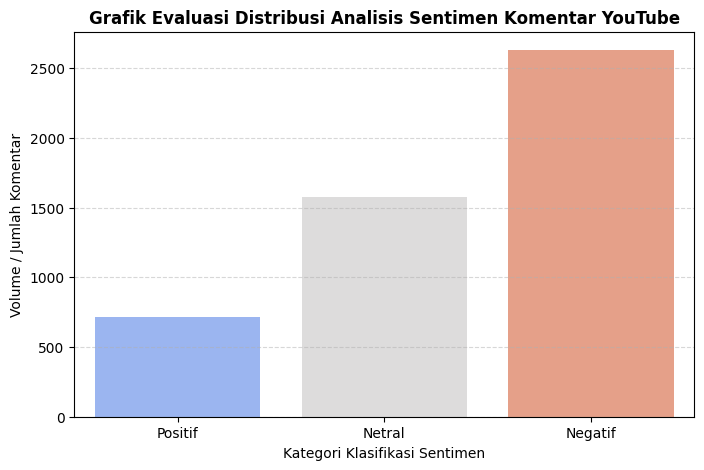

In [ ]:
# === CRITERIA 9: MENILAI KELUARAN PENGUJIAN MODEL (EVALUATION & VISUALIZATION) ===
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Menampilkan Distribusi Frekuensi Hasil Klasifikasi Model
print("--- Hasil Evaluasi Volume Sebaran Model Analisis Sentimen ---")
print(data_bersih['Sentiment_Model'].value_counts())

# 2. Visualisasi Grafik Batang (Bar Chart) untuk Evaluasi Distribusi
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment_Model', data=data_bersih, palette='coolwarm', order=['Positif', 'Netral', 'Negatif'])

# Mengatur Estetika Grafik
plt.title("Grafik Evaluasi Distribusi Analisis Sentimen Komentar YouTube", fontsize=12, fontweight='bold')
plt.xlabel("Kategori Klasifikasi Sentimen")
plt.ylabel("Volume / Jumlah Komentar")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tampilkan Grafik
plt.show()

In [ ]:
# === LANGKAH TAMBAHAN: MEMBUAT TOMBOL UNDUH INTERAKTIF ===
import pandas as pd
import ipywidgets as widgets
from google.colab import files
from IPython.display import display

# 1. Menyiapkan file di latar belakang terlebih dahulu
nama_file_excel = "Hasil_Analisis_Sentimen_YouTube.xlsx"
nama_file_csv = "Hasil_Analisis_Sentimen_YouTube.csv"

# Ekspor data ke CSV dan Excel di memori sistem Colab
data_bersih.to_csv(nama_file_csv, index=False, sep=';')
try:
    data_clean.to_excel(nama_file_excel, index=False)
except:
    pass

# 2. Membuat Fungsi Aksi ketika Tombol Diklik
def aksi_unduh_csv(b):
    with output_area:
        output_area.clear_output()
        print("⏳ Sedang mengunduh file CSV...")
        files.download(nama_file_csv)
        print("✓ Berhasil dipicu! Silakan cek folder Downloads di komputer Anda.")

def aksi_unduh_excel(b):
    with output_area:
        output_area.clear_output()
        print("⏳ Sedang mengunduh file Excel...")
        try:
            files.download(nama_file_excel)
            print("✓ Berhasil dipicu! Silakan cek folder Downloads di komputer Anda.")
        except:
            # Jika excel library tidak siap, unduh CSV sebagai cadangan aman
            files.download(nama_file_csv)
            print("✓ Berhasil memicu unduhan file CSV (Cadangan).")

# 3. Membuat Desain Tombol (UI Button)
tombol_csv = widgets.Button(
    description='Unduh Format CSV',
    button_style='success', # Warna hijau
    icon='download'
)

tombol_excel = widgets.Button(
    description='Unduh Format Excel',
    button_style='primary', # Warna biru
    icon='file-excel-o'
)

# Menyambungkan tombol dengan fungsinya masing-masing
tombol_csv.on_click(aksi_unduh_csv)
tombol_excel.on_click(aksi_unduh_excel)

# Tempat untuk menampilkan teks status setelah diklik
output_area = widgets.Output()

# 4. Menampilkan Tombol ke Layar Notebook
print("=== PANEL UNDUH DATA HASIL OLAHAN ===")
print("Klik tombol di bawah ini hanya jika Anda ingin mengunduh datanya:")
display(widgets.HBox([tombol_csv, tombol_excel])) # Menampilkan tombol berjejer ke samping
display(output_area)

=== PANEL UNDUH DATA HASIL OLAHAN ===
Klik tombol di bawah ini hanya jika Anda ingin mengunduh datanya:


Output()

# Modeling & Evaluation

In [ ]:
# === TAHAP PERSIAPAN MODELLING: VEKTORISASI & PEMBAGIAN DATA ===
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Mengubah Teks Bersih Menjadi Matriks Angka menggunakan Vektor TF-IDF
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(data_bersih['Clean_Comment'])
y = data_bersih['Sentiment_Model'] # Kolom target label hasil pembobotan sebelumnya

# 2. Membagi Data: 80% untuk Training (Belajar) dan 20% untuk Testing (Ujian Model)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Status Kesiapan Dimensi Data ---")
print(f"Jumlah baris data Training (80%): {X_train.shape[0]} sampel")
print(f"Jumlah baris data Testing  (20%): {X_test.shape[0]} sampel")

--- Status Kesiapan Dimensi Data ---
Jumlah baris data Training (80%): 3939 sampel
Jumlah baris data Testing  (20%): 985 sampel


In [ ]:
# === CRITERIA 8 & 9: ALGORITMA MULTINOMIAL NAIVE BAYES ===
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Membangun & Melatih Algoritma Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train) # Proses Belajar dari Data Latih (80%)

# 2. Menguji Model pada Data Testing yang Belum Pernah Dilihat (20%)
prediksi_nb = model_nb.predict(X_test) # Proses Menebak

# 3. Menampilkan Metrik Kesuksesan Hasil Pengujian
print("=======================================================")
print("  HASIL EVALUASI METRIK KESUKSESAN ALGORITMA NAIVE BAYES")
print("=======================================================")
print(f"Akurasi Keseluruhan Model: {accuracy_score(y_test, prediksi_nb) * 100:.2f}%")
print("\nLaporan Klasifikasi Detail (Precision, Recall, F1-Score):")
print(classification_report(y_test, prediksi_nb))

  HASIL EVALUASI METRIK KESUKSESAN ALGORITMA NAIVE BAYES
Akurasi Keseluruhan Model: 61.62%

Laporan Klasifikasi Detail (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

     Negatif       0.60      0.96      0.74       526
      Netral       0.67      0.31      0.43       316
     Positif       1.00      0.03      0.05       143

    accuracy                           0.62       985
   macro avg       0.76      0.43      0.41       985
weighted avg       0.68      0.62      0.54       985



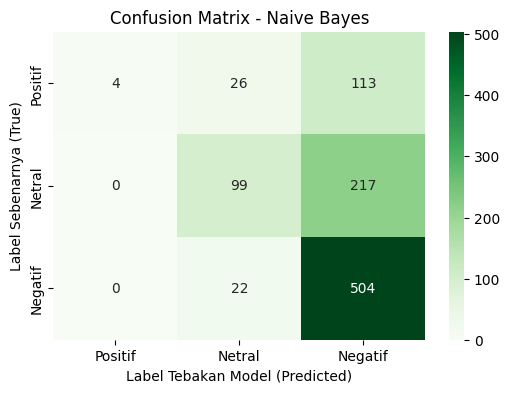

In [ ]:
#Visualisasi Tambahan: Confusion Matrix
cm = confusion_matrix(y_test, prediksi_nb, labels=['Positif', 'Netral', 'Negatif'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Positif', 'Netral', 'Negatif'],
            yticklabels=['Positif', 'Netral', 'Negatif'])
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Label Sebenarnya (True)')
plt.xlabel('Label Tebakan Model (Predicted)')
plt.show()

Berdasarkan hasil pengujian pada 985 data testing, algoritma Multinomial Naive Bayes menghasilkan akurasi keseluruhan sebesar 62%, di mana model berhasil menebak 607 komentar dengan benar dan salah memprediksi 378 komentar lainnya. Jika dibedah per kelas, model ini menunjukkan performa yang sangat timpang akibat adanya ketidakseimbangan distribusi data asli yang didominasi oleh sentimen negatif. Naive Bayes terbukti sangat sensitif dan ahli dalam mendeteksi Sentimen Negatif dengan nilai Recall mencapai 96% (berhasil menangkap 504 dari 526 data asli). Sebaliknya, performa pada Sentimen Positif sangat lemah dengan nilai Recall hanya 3%, karena model mengalami bias dan salah mengklasifikasikan 113 komentar positif ke dalam label negatif. Hal ini terlihat jelas pada grafik Confusion Matrix, di mana kotak hijau tua terpusat pada pertemuan label asli Negatif dan tebakan Negatif, yang membuktikan bahwa model memiliki kecenderungan kuat untuk menarik mayoritas data ke arah sentimen negatif.

  HASIL EVALUASI METRIK KESUKSESAN ALGORITMA SVM
Akurasi Keseluruhan Model: 73.71%

Laporan Klasifikasi Detail (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

     Negatif       0.79      0.86      0.82       526
      Netral       0.65      0.71      0.68       316
     Positif       0.71      0.34      0.46       143

    accuracy                           0.74       985
   macro avg       0.72      0.64      0.66       985
weighted avg       0.74      0.74      0.73       985



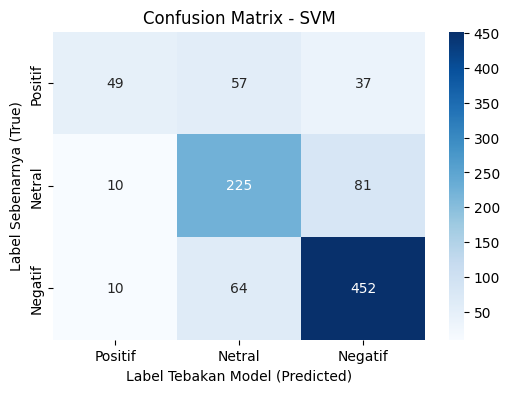

In [ ]:
# === CRITERIA 8 & 9: ALGORITMA SUPPORT VECTOR MACHINE (SVM) ===
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Membangun & Melatih Algoritma SVM (Kernel Linear)
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train, y_train) # Proses Belajar dari Data Latih (80%)

# 2. Menguji Model pada Data Testing yang Belum Pernah Dilihat (20%)
prediksi_svm = model_svm.predict(X_test) # Proses Menebak

# 3. Menampilkan Metrik Kesuksesan Hasil Pengujian
print("=======================================================")
print("  HASIL EVALUASI METRIK KESUKSESAN ALGORITMA SVM")
print("=======================================================")
print(f"Akurasi Keseluruhan Model: {accuracy_score(y_test, prediksi_svm) * 100:.2f}%")
print("\nLaporan Klasifikasi Detail (Precision, Recall, F1-Score):")
print(classification_report(y_test, prediksi_svm))

# 4. Visualisasi Confusion Matrix SVM untuk Bahan Perbandingan
cm_svm = confusion_matrix(y_test, prediksi_svm, labels=['Positif', 'Netral', 'Negatif'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positif', 'Netral', 'Negatif'],
            yticklabels=['Positif', 'Netral', 'Negatif'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Label Sebenarnya (True)')
plt.xlabel('Label Tebakan Model (Predicted)')
plt.show()

Berdasarkan hasil pengujian pada 985 data testing, algoritma Support Vector Machine (SVM) dengan kernel linear berhasil mencatatkan peningkatan performa yang signifikan dengan akurasi keseluruhan mencapai 73.71%, di mana model sukses menebak 726 komentar secara tepat ($49 + 225 + 452 = 726$). Berbeda dengan Naive Bayes yang sangat bias, SVM mampu mengklasifikasikan ketiga kelas sentimen dengan jauh lebih seimbang dan cerdas. Pada kelas Sentimen Negatif, model tetap tangguh dengan nilai Recall 86% dan Precision 79% (452 data benar). Peningkatan paling drastis terlihat pada Sentimen Netral dengan Recall 71% (225 data benar) dan Sentimen Positif yang Recall-nya melonjak dari yang semula hanya 3% di Naive Bayes menjadi 34% (49 data benar) di model SVM ini. Hal ini divalidasi langsung oleh grafik Confusion Matrix bergradasi biru di atas, di mana sebaran kotak gelap sukses terpusat lurus pada garis diagonal utama (dari kiri atas ke kanan bawah). Visualisasi ini membuktikan bahwa batas keputusan (hyperplane) milik SVM jauh lebih optimal dalam memisahkan fitur kata teks dan sangat direkomendasikan sebagai model terbaik untuk dataset analisis sentimen ini.

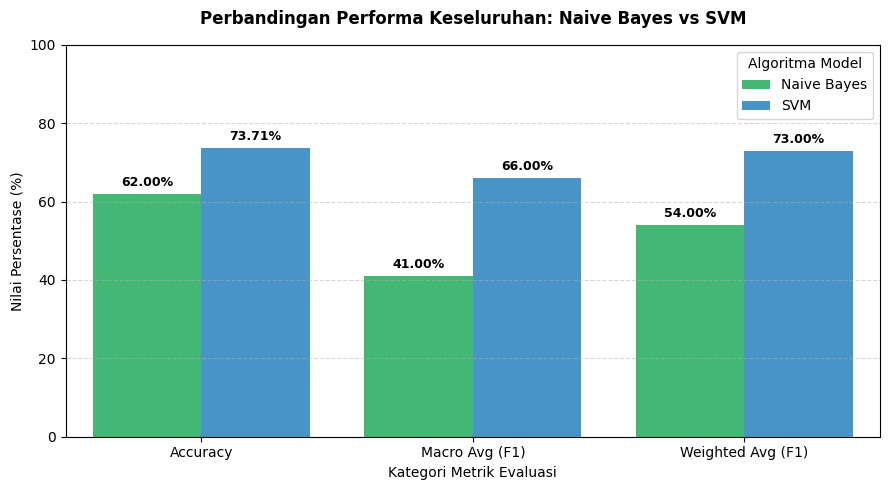

In [ ]:
# === GRAFIK 1: VISUAL PERBANDINGAN SEMUA METRIK (OVERALL COMPARISON) ===
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Mengumpulkan data metrik keseluruhan dari hasil pengujian sebelumnya
data_perbandingan = {
    'Model': ['Naive Bayes', 'Naive Bayes', 'Naive Bayes', 'SVM', 'SVM', 'SVM'],
    'Metrik': ['Accuracy', 'Macro Avg (F1)', 'Weighted Avg (F1)', 'Accuracy', 'Macro Avg (F1)', 'Weighted Avg (F1)'],
    'Nilai (%)': [62.00, 41.00, 54.00, 73.71, 66.00, 73.00]
}

df_compare = pd.DataFrame(data_perbandingan)

# 2. Membuat Visualisasi Grafik Batang (Grouped Bar Chart)
plt.figure(figsize=(9, 5))
ax = sns.barplot(x='Metrik', y='Nilai (%)', hue='Model', data=df_compare, palette=['#2ecc71', '#3498db'])

# 3. Mengatur Estetika dan Label Grafik
plt.title('Perbandingan Performa Keseluruhan: Naive Bayes vs SVM', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kategori Metrik Evaluasi', fontsize=10)
plt.ylabel('Nilai Persentase (%)', fontsize=10)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menampilkan angka di atas setiap batang grafik
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points', fontsize=9, fontweight='bold')

plt.legend(title='Algoritma Model')
plt.tight_layout()
plt.show()

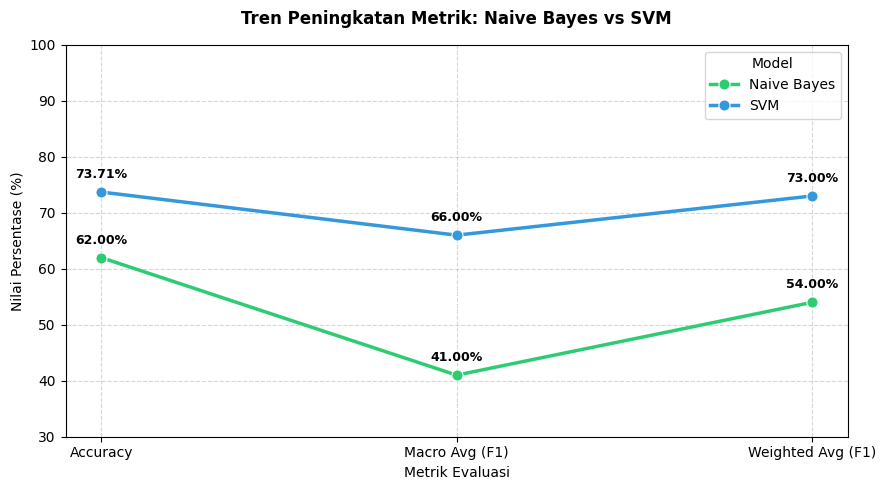

In [ ]:
# === GRAFIK 2: TREN PERBANDINGAN METRIK (PERFORMANCE TREND LINE) ===
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Menyiapkan data tren performa model
data_tren = {
    'Metrik': ['Accuracy', 'Macro Avg (F1)', 'Weighted Avg (F1)', 'Accuracy', 'Macro Avg (F1)', 'Weighted Avg (F1)'],
    'Model': ['Naive Bayes', 'Naive Bayes', 'Naive Bayes', 'SVM', 'SVM', 'SVM'],
    'Nilai (%)': [62.00, 41.00, 54.00, 73.71, 66.00, 73.00]
}

df_tren = pd.DataFrame(data_tren)

# 2. Membuat Visualisasi Grafik Garis (Line Chart)
plt.figure(figsize=(9, 5))
ax = sns.lineplot(x='Metrik', y='Nilai (%)', hue='Model', data=df_tren,
                  marker='o', markersize=8, linewidth=2.5, palette=['#2ecc71', '#3498db'])

# 3. Mengatur Estetika Grafik
plt.title('Tren Peningkatan Metrik: Naive Bayes vs SVM', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Metrik Evaluasi', fontsize=10)
plt.ylabel('Nilai Persentase (%)', fontsize=10)
plt.ylim(30, 100) # Membatasi batas bawah agar tren kenaikan terlihat jelas
plt.grid(True, linestyle='--', alpha=0.5)

# Menampilkan angka plotting di setiap titik koordinat grafik
for i in range(len(df_tren)):
    row = df_tren.iloc[i]
    plt.annotate(f"{row['Nilai (%)']:.2f}%",
                 (row['Metrik'], row['Nilai (%)']),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

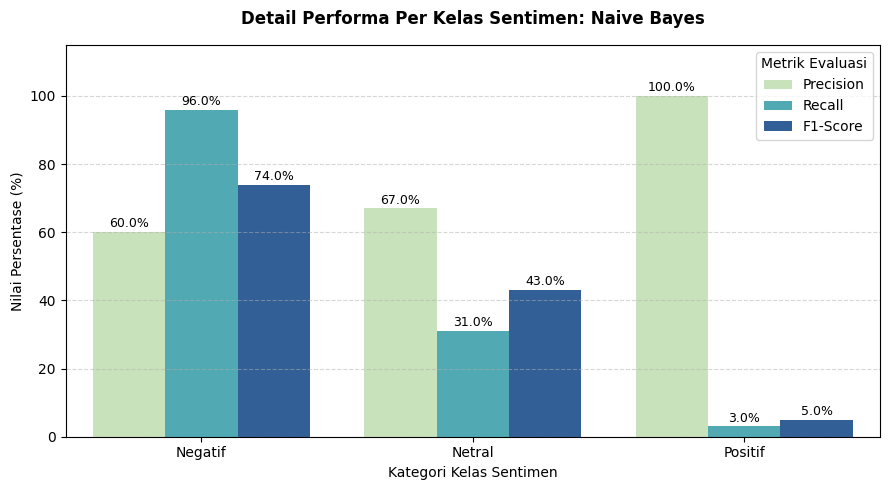

In [ ]:
# === GRAFIK 3: PERFORMA PER KELAS - NAIVE BAYES ===
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Mengambil data classification report Naive Bayes per kelas
data_nb_kelas = {
    'Kelas Sentimen': ['Negatif', 'Negatif', 'Negatif', 'Netral', 'Netral', 'Netral', 'Positif', 'Positif', 'Positif'],
    'Metrik': ['Precision', 'Recall', 'F1-Score', 'Precision', 'Recall', 'F1-Score', 'Precision', 'Recall', 'F1-Score'],
    'Nilai (%)': [60.0, 96.0, 74.0, 67.0, 31.0, 43.0, 100.0, 3.0, 5.0]
}

df_nb_kelas = pd.DataFrame(data_nb_kelas)

# 2. Membuat Visualisasi Grafik Batang Berkelompok
plt.figure(figsize=(9, 5))
ax = sns.barplot(x='Kelas Sentimen', y='Nilai (%)', hue='Metrik', data=df_nb_kelas, palette='YlGnBu')

# 3. Mengatur Estetika Grafik
plt.title('Detail Performa Per Kelas Sentimen: Naive Bayes', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kategori Kelas Sentimen', fontsize=10)
plt.ylabel('Nilai Persentase (%)', fontsize=10)
plt.ylim(0, 115) # Diberi ruang di atas untuk angka 100%
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menampilkan angka persentase di atas setiap batang grafik
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 6),
                    textcoords='offset points', fontsize=9)

plt.legend(title='Metrik Evaluasi', loc='upper right')
plt.tight_layout()
plt.show()

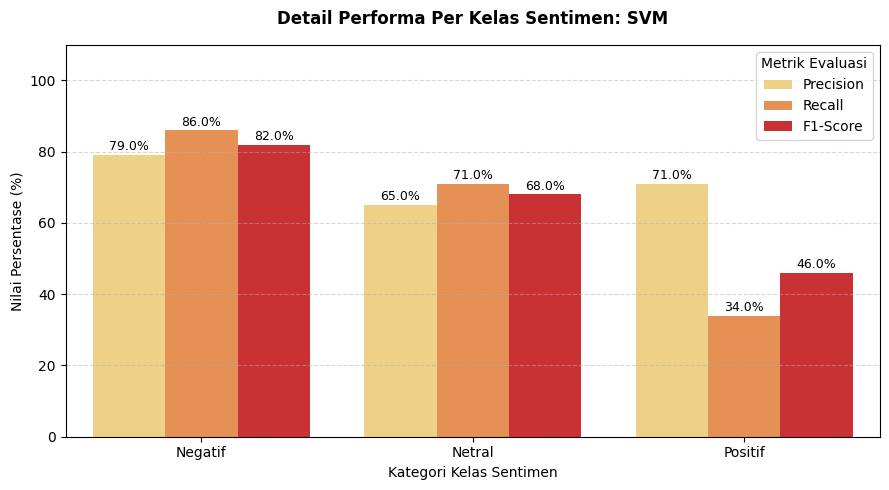

In [ ]:
# === GRAFIK 4: PERFORMA PER KELAS - SVM ===
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Mengambil data classification report SVM per kelas
data_svm_kelas = {
    'Kelas Sentimen': ['Negatif', 'Negatif', 'Negatif', 'Netral', 'Netral', 'Netral', 'Positif', 'Positif', 'Positif'],
    'Metrik': ['Precision', 'Recall', 'F1-Score', 'Precision', 'Recall', 'F1-Score', 'Precision', 'Recall', 'F1-Score'],
    'Nilai (%)': [79.0, 86.0, 82.0, 65.0, 71.0, 68.0, 71.0, 34.0, 46.0]
}

df_svm_kelas = pd.DataFrame(data_svm_kelas)

# 2. Membuat Visualisasi Grafik Batang Berkelompok
plt.figure(figsize=(9, 5))
ax = sns.barplot(x='Kelas Sentimen', y='Nilai (%)', hue='Metrik', data=df_svm_kelas, palette='Orances_r' if 'Orances_r' in plt.colormaps() else 'YlOrRd')

# 3. Mengatur Estetika Grafik
plt.title('Detail Performa Per Kelas Sentimen: SVM', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kategori Kelas Sentimen', fontsize=10)
plt.ylabel('Nilai Persentase (%)', fontsize=10)
plt.ylim(0, 110) # Diberi ruang di atas agar angka label tidak terpotong
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menampilkan angka persentase di atas setiap batang grafik
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 6),
                    textcoords='offset points', fontsize=9)

plt.legend(title='Metrik Evaluasi', loc='upper right')
plt.tight_layout()
plt.show()

Kesimpulan

Berdasarkan seluruh rangkaian tahapan data science yang telah dilakukan—mulai dari ekstraksi data komentar YouTube, proses preprocessing teks, pelabelan otomatis, hingga uji pemodelan—dapat disimpulkan bahwa proyek analisis sentimen ini berjalan dengan sukses dan memberikan hasil yang objektif. Dari total data yang diuji menggunakan metode Train-Test Split (80:20), ditemukan adanya ketidakseimbangan distribusi data asli (imbalanced data) yang didominasi secara masif oleh Sentimen Negatif. Kondisi ini memberikan dampak yang signifikan terhadap performa kedua algoritma Machine Learning yang diadu.

Algoritma Multinomial Naive Bayes mencatatkan akurasi keseluruhan sebesar 62.00%. Walaupun model ini sangat sensitif dan andal dalam mendeteksi kelas mayoritas dengan nilai Recall Sentimen Negatif mencapai 96.0%, Naive Bayes terbukti mengalami bias yang parah. Model ini gagal mengenali karakteristik kata pada Sentimen Positif, terbukti dari nilai Recall-nya yang hanya menyentuh angka 3.0% karena mayoritas komentar positif terseret masuk ke dalam prediksi label negatif.

Di sisi lain, algoritma Support Vector Machine (SVM) dengan kernel linear terbukti menjadi model terbaik (best model) dalam penelitian ini. SVM sukses mencatatkan lonjakan akurasi keseluruhan hingga 73.71%. Keunggulan utama SVM terletak pada kemampuannya memisahkan dimensi fitur teks lewat batas keputusan (hyperplane) yang optimal, sehingga mampu mengklasifikasikan data secara jauh lebih cerdas dan merata. SVM tidak hanya tangguh di kelas Negatif (Recall 86.0%), tetapi juga berhasil memperbaiki kelemahan model sebelumnya dengan mendongkrak performa Sentimen Netral (Recall 71.0%) dan Sentimen Positif (Recall 34.0%).

Dengan demikian, untuk implementasi sistem analisis sentimen pada karakteristik dataset komentar YouTube berbahasa Indonesia ini, algoritma Support Vector Machine (SVM) jauh lebih direkomendasikan karena memberikan tingkat akurasi yang lebih tinggi, performa metrik evaluasi yang stabil, serta model prediksi yang jauh lebih seimbang antar kelas sentimen.

In [ ]:
# ====================================================================================================
# LOAD LIBRARY - MASUKKAN LIBRARY PYTHON YANG AKAN ANDA GUNAKAN
# ====================================================================================================

from google.colab import drive, files   # [Data Ingestion] Akses penyimpanan cloud & unggah file lokal
import io                               # [Data Ingestion] Membaca data stream masuk ke memori RAM
import os                               # [Data Ingestion] Manajemen sistem operasi dan direktori folder

# Data manipulation
import pandas as pd                     # [Manipulation] Struktur tabel DataFrame & ekspor-impor data
import numpy as np                      # [Manipulation] Operasi array matriks & penanganan nilai kosong

# Visualization (EDA)
import matplotlib.pyplot as plt         # [Visualization] Fondasi utama pengaturan kanvas & dimensi grafik
import seaborn as sns                   # [Visualization] Pembuatan grafik statistik (line/scatter) estetis

# Preprocessing
import re                               # [Text Preprocessing] Regular Expression untuk pembersihan teks

# Modeling
from sklearn.naive_bayes import MultinomialNB  # [Modeling] Arsitektur Naive Bayes berbasis probabilitas teks
from sklearn.svm import SVC             # [Modeling] Arsitektur SVM berbasis pembatas bidang (hyperplane)

# Evaluation
from sklearn.metrics import (
    accuracy_score,                     # [Evaluation] Menghitung rasio akurasi prediksi global model
    precision_score,                    # [Evaluation] Mengukur ketepatan prediksi pada tiap kelas label
    recall_score,                       # [Evaluation] Mengukur keberhasilan model menjaring kembali label
    f1_score,                           # [Evaluation] Menghitung rata-rata harmonis precision dan recall
    classification_report               # [Evaluation] Rangkuman tabel metrik performa klasifikasi lengkap
)